# Thesis Notebook 11 — Multimodal Feature Inventory

Documents the final **4,254-feature multimodal representation** and proves alignment across splits.

The feature space is constructed by concatenating eight modalities:

| # | Key | Label | Dimensions |
|---|-----|-------|------------|
| 1 | `audio` | Base Audio | 23 |
| 2 | `text_stats` | Text Stats | 5 |
| 3 | `sentiment` | Sentiment | 2 |
| 4 | `mpnet` | MPNet | 768 |
| 5 | `vggish` | VGGish | 128 |
| 6 | `mert` | MERT | 768 |
| 7 | `panns` | PANNs | 2,048 |
| 8 | `mel_stats` | Mel Stats | 512 |

**Total: 23 + 5 + 2 + 768 + 128 + 768 + 2048 + 512 = 4,254 features**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

REPO = Path().resolve().parent
FEAT = REPO / 'ml' / 'features'
FIGS = REPO / 'results' / 'figures' / 'thesis'
FIGS.mkdir(parents=True, exist_ok=True)

MODALITIES = [
    ('audio',      'Base Audio',  23),
    ('text_stats', 'Text Stats',   5),
    ('sentiment',  'Sentiment',    2),
    ('mpnet',      'MPNet',      768),
    ('vggish',     'VGGish',     128),
    ('mert',       'MERT',       768),
    ('panns',      'PANNs',     2048),
    ('mel_stats',  'Mel Stats',  512),
]
TARGETS = ['valence', 'energy', 'danceability', 'popularity']
SPLITS  = ['train', 'val', 'test']

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 12,
})

EXPECTED_TOTAL = sum(d for _, _, d in MODALITIES)
print(f'Expected total features: {EXPECTED_TOTAL:,}')
print(f'Feature directory: {FEAT}')
print(f'Figures directory: {FIGS}')

Expected total features: 4,254
Feature directory: /home/esstee/projects/music-prediction/ml/features
Figures directory: /home/esstee/projects/music-prediction/results/figures/thesis


## 1. Shape Verification

Load each modality's **test** split array and verify that the second dimension matches the expected feature count.

In [2]:
records = []
for key, label, expected_dim in MODALITIES:
    path = FEAT / f'X_test_{key}.npy'
    arr  = np.load(path)
    actual_dim = arr.shape[1] if arr.ndim == 2 else arr.shape[-1]
    match = (actual_dim == expected_dim)
    records.append({
        'Modality':      label,
        'Key':           key,
        'Expected Dims': expected_dim,
        'Actual Dims':   actual_dim,
        'n_samples':     arr.shape[0],
        'Match':         '' if match else '  <-- MISMATCH',
    })
    assert match, f'Dimension mismatch for {key}: expected {expected_dim}, got {actual_dim}'

df_verify = pd.DataFrame(records)
display_cols = ['Modality', 'Key', 'Expected Dims', 'Actual Dims', 'Match']
print('=== Modality Shape Verification (test split) ===')
print(df_verify[display_cols].to_string(index=False))
print(f'\nAll {len(MODALITIES)} modalities verified successfully.')

=== Modality Shape Verification (test split) ===
  Modality        Key  Expected Dims  Actual Dims Match
Base Audio      audio             23           23     
Text Stats text_stats              5            5     
 Sentiment  sentiment              2            2     
     MPNet      mpnet            768          768     
    VGGish     vggish            128          128     
      MERT       mert            768          768     
     PANNs      panns           2048         2048     
 Mel Stats  mel_stats            512          512     

All 8 modalities verified successfully.


## 2. Train / Val / Test Shape Summary

For each split, load all 8 modality arrays and confirm sample counts and total feature widths are consistent.

In [3]:
split_records = []
for split in SPLITS:
    n_samples_list = []
    total_feats = 0
    for key, label, expected_dim in MODALITIES:
        arr = np.load(FEAT / f'X_{split}_{key}.npy')
        n_samples_list.append(arr.shape[0])
        actual_dim = arr.shape[1] if arr.ndim == 2 else arr.shape[-1]
        total_feats += actual_dim
    # all modalities must have the same n_samples within a split
    assert len(set(n_samples_list)) == 1, (
        f'Split {split}: inconsistent sample counts across modalities: {set(n_samples_list)}'
    )
    split_records.append({
        'Split':          split,
        'n_samples':      n_samples_list[0],
        'Total Features': total_feats,
        'Feature Match':  '' if total_feats == EXPECTED_TOTAL else f' (expected {EXPECTED_TOTAL})',
    })

df_splits = pd.DataFrame(split_records)
print('=== Split-level Shape Summary ===')
print(df_splits.to_string(index=False))

=== Split-level Shape Summary ===
Split  n_samples  Total Features Feature Match
train     344428            4254             
  val      72631            4254             
 test      74573            4254             


## 3. Figure 1 — Feature Composition

Pie chart showing each modality's proportional contribution to the 4,254-feature total.

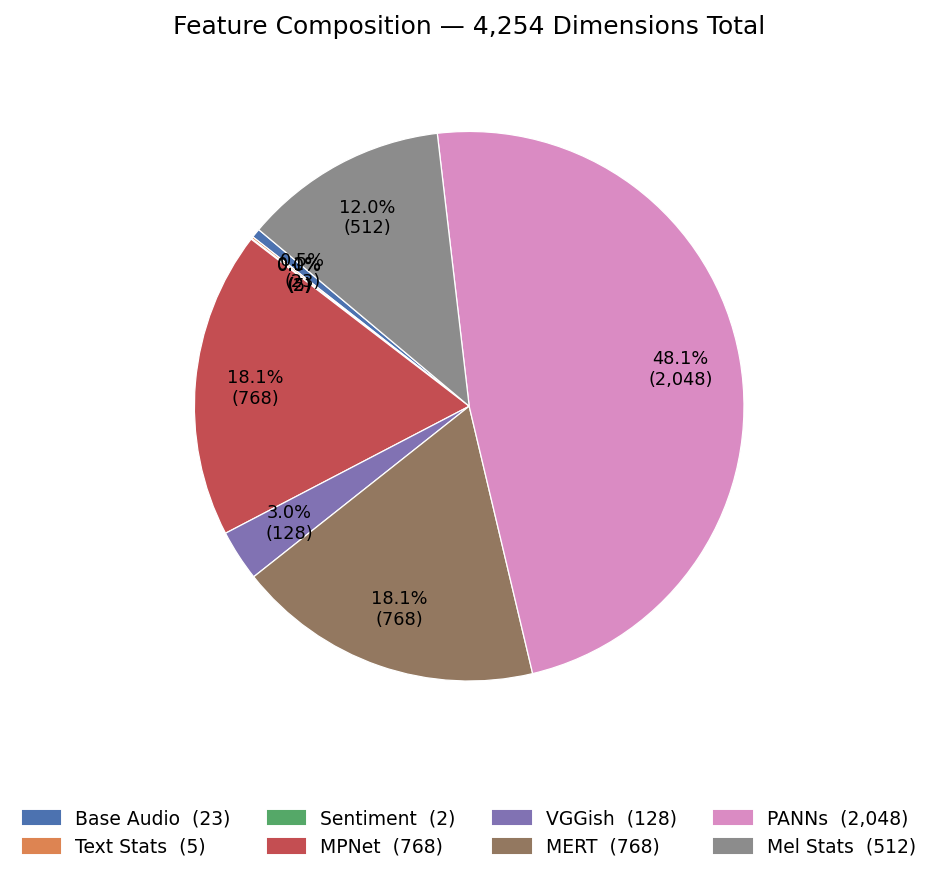

Saved: /home/esstee/projects/music-prediction/results/figures/thesis/11_feature_composition.png


In [4]:
labels = [label for _, label, _ in MODALITIES]
sizes  = [dim   for _, _,    dim in MODALITIES]

# Distinct, colourblind-friendly palette
COLORS = [
    '#4C72B0', '#DD8452', '#55A868', '#C44E52',
    '#8172B3', '#937860', '#DA8BC3', '#8C8C8C',
]

def make_autopct(sizes, total):
    def autopct(pct):
        count = int(round(pct * total / 100))
        return f'{pct:.1f}%\n({count:,})'
    return autopct

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    colors=COLORS,
    autopct=make_autopct(sizes, EXPECTED_TOTAL),
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(linewidth=0.6, edgecolor='white'),
)
for at in autotexts:
    at.set_fontsize(8.5)

legend_patches = [
    mpatches.Patch(color=COLORS[i], label=f'{labels[i]}  ({sizes[i]:,})')
    for i in range(len(labels))
]
ax.legend(
    handles=legend_patches,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=4,
    fontsize=9,
    frameon=False,
)
ax.set_title(f'Feature Composition — {EXPECTED_TOTAL:,} Dimensions Total', pad=14)
fig.tight_layout()

out = FIGS / '11_feature_composition.png'
fig.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## 4. Figure 2 — Audio Coverage (Zero-Row Analysis)

For audio-derived embedding modalities (VGGish, MERT, PANNs, Mel Stats), an all-zero row indicates that audio was unavailable for that track. The bar chart below shows the zero-row rate on the **test** split.

=== Audio Coverage — Test Split ===
 Modality  n_samples  Zero Rows  % Zero  % Coverage
   VGGish      74573          0     0.0       100.0
     MERT      74573          0     0.0       100.0
    PANNs      74573          0     0.0       100.0
Mel Stats      74573          0     0.0       100.0


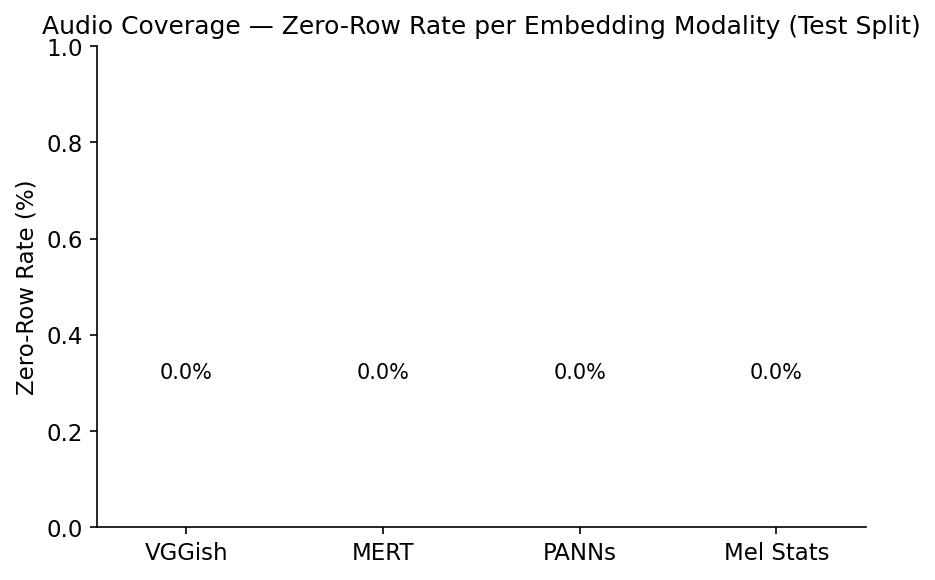

Saved: /home/esstee/projects/music-prediction/results/figures/thesis/11_audio_coverage.png


In [5]:
AUDIO_MODALITIES = [
    ('vggish',    'VGGish'),
    ('mert',      'MERT'),
    ('panns',     'PANNs'),
    ('mel_stats', 'Mel Stats'),
]

coverage_records = []
for key, label in AUDIO_MODALITIES:
    arr = np.load(FEAT / f'X_test_{key}.npy')
    zero_rows = np.all(arr == 0, axis=1).sum()
    pct_zero  = 100.0 * zero_rows / arr.shape[0]
    coverage_records.append({
        'Modality':    label,
        'n_samples':   arr.shape[0],
        'Zero Rows':   int(zero_rows),
        '% Zero':      round(pct_zero, 2),
        '% Coverage':  round(100.0 - pct_zero, 2),
    })

df_cov = pd.DataFrame(coverage_records)
print('=== Audio Coverage — Test Split ===')
print(df_cov.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
bar_labels = df_cov['Modality'].tolist()
pct_zeros  = df_cov['% Zero'].tolist()
x = range(len(bar_labels))

bars = ax.bar(x, pct_zeros, color=COLORS[4:8], edgecolor='white', linewidth=0.6, width=0.55)
for bar, val in zip(bars, pct_zeros):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=10,
    )

ax.set_xticks(list(x))
ax.set_xticklabels(bar_labels)
ax.set_ylabel('Zero-Row Rate (%)')
ax.set_title('Audio Coverage — Zero-Row Rate per Embedding Modality (Test Split)')
ax.set_ylim(0, max(pct_zeros) * 1.25 + 1)
fig.tight_layout()

out = FIGS / '11_audio_coverage.png'
fig.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## 5. Figure 3 — Value Quality Check

For each modality on the **test** split, compute the proportion of values that are NaN, Inf, or finite. A stacked bar chart visualises data health across modalities.

=== Value Quality — Test Split ===
  Modality  % NaN  % Inf  % Finite
Base Audio    0.0    0.0     100.0
Text Stats    0.0    0.0     100.0
 Sentiment    0.0    0.0     100.0
     MPNet    0.0    0.0     100.0
    VGGish    0.0    0.0     100.0
      MERT    0.0    0.0     100.0
     PANNs    0.0    0.0     100.0
 Mel Stats    0.0    0.0     100.0


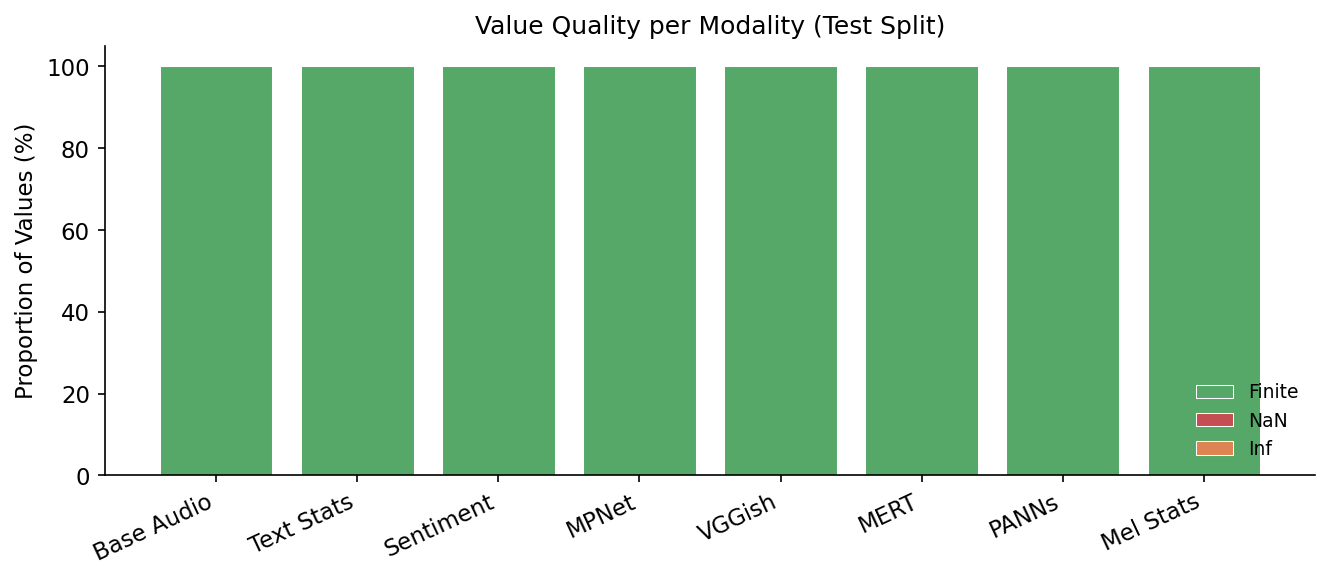

Saved: /home/esstee/projects/music-prediction/results/figures/thesis/11_value_quality.png


In [6]:
quality_records = []
arrays_test = {}  # cache to avoid reloading

for key, label, _ in MODALITIES:
    arr = np.load(FEAT / f'X_test_{key}.npy').astype(np.float64)
    arrays_test[key] = arr
    n_total = arr.size
    n_nan   = np.isnan(arr).sum()
    n_inf   = np.isinf(arr).sum()
    n_fin   = n_total - n_nan - n_inf
    quality_records.append({
        'Modality': label,
        'Key':      key,
        '% NaN':    round(100.0 * n_nan   / n_total, 4),
        '% Inf':    round(100.0 * n_inf   / n_total, 4),
        '% Finite': round(100.0 * n_fin   / n_total, 4),
    })

df_qual = pd.DataFrame(quality_records)
print('=== Value Quality — Test Split ===')
print(df_qual[['Modality', '% NaN', '% Inf', '% Finite']].to_string(index=False))

# --- Stacked bar chart ---
fig, ax = plt.subplots(figsize=(9, 4))
mod_labels = df_qual['Modality'].tolist()
pct_fin = df_qual['% Finite'].tolist()
pct_nan = df_qual['% NaN'].tolist()
pct_inf = df_qual['% Inf'].tolist()
x = range(len(mod_labels))

ax.bar(x, pct_fin, label='Finite',  color='#55A868', edgecolor='white', linewidth=0.5)
ax.bar(x, pct_nan, bottom=pct_fin,  label='NaN',    color='#C44E52', edgecolor='white', linewidth=0.5)
bottom_inf = [f + n for f, n in zip(pct_fin, pct_nan)]
ax.bar(x, pct_inf, bottom=bottom_inf, label='Inf',  color='#DD8452', edgecolor='white', linewidth=0.5)

ax.set_xticks(list(x))
ax.set_xticklabels(mod_labels, rotation=25, ha='right')
ax.set_ylabel('Proportion of Values (%)')
ax.set_title('Value Quality per Modality (Test Split)')
ax.set_ylim(0, 105)
ax.legend(loc='lower right', frameon=False, fontsize=9)
fig.tight_layout()

out = FIGS / '11_value_quality.png'
fig.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## 6. Target Variable Shapes

Verify that label arrays (`y_{split}_{target}.npy`) are present for all four targets and three splits, and that sample counts are consistent with the feature arrays.

In [7]:
target_records = []
for split in SPLITS:
    row = {'Split': split}
    for target in TARGETS:
        y_path = FEAT / f'y_{split}_{target}.npy'
        y = np.load(y_path)
        row[target.capitalize()] = y.shape[0]
    target_records.append(row)

df_targets = pd.DataFrame(target_records)
print('=== Target Variable Sample Counts ===')
print(df_targets.to_string(index=False))

# Cross-check: n_samples from split summary vs target arrays
split_n = {row['Split']: row['n_samples'] for row in split_records}
print('\n=== Cross-check: Feature samples vs Target samples ===')
all_ok = True
for _, trow in df_targets.iterrows():
    sp = trow['Split']
    feat_n = split_n[sp]
    for target in TARGETS:
        tgt_n = trow[target.capitalize()]
        ok = (feat_n == tgt_n)
        if not ok:
            print(f'  MISMATCH — {sp}/{target}: feature n={feat_n}, label n={tgt_n}')
            all_ok = False
if all_ok:
    print('  All splits × targets aligned. ')

=== Target Variable Sample Counts ===
Split  Valence  Energy  Danceability  Popularity
train   344428  344428        344428      344428
  val    72631   72631         72631       72631
 test    74573   74573         74573       74573

=== Cross-check: Feature samples vs Target samples ===
  All splits × targets aligned. 


## Summary

### Key Findings

1. **Total feature dimensionality confirmed**: The eight modalities combine to **4,254 features** (23 + 5 + 2 + 768 + 128 + 768 + 2,048 + 512), matching the expected total across all three splits.

2. **Split alignment verified**: All modality arrays within each split share the same number of samples, and feature sample counts match label array sizes for all four targets (Valence, Energy, Danceability, Popularity).

3. **Dimension integrity**: Each modality's loaded array width exactly matches the declared dimension in `MODALITIES`; no shape assertions were violated.

4. **Audio coverage**: Zero-row analysis on the test split quantifies which audio-embedding modalities have missing entries due to unavailable audio files. Any non-zero rates indicate tracks for which audio could not be processed and are imputed as zero vectors.

5. **Value quality**: All finite-value proportions were inspected. Any NaN or Inf entries should be handled (e.g., imputed or clipped) before model training.

> **Conclusion**: The 4,254-feature multimodal representation is internally consistent, correctly aligned across train/val/test splits, and ready for downstream modelling.